In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Advanced Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

In [ ]:
df = pd.read_csv("heart.csv")

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.info()
df.size
df["HeartDisease"].value_counts()  # Check the distribution of the target variable

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


HeartDisease
1    508
0    410
Name: count, dtype: int64

In [ ]:
df.isnull().sum()  # Check for missing values
df.drop_duplicates(inplace=True)  # Remove duplicate rows if any

In [ ]:
df["Sex"] = df["Sex"].str.strip()
df["Sex"] = df["Sex"].map({"M": 1, "F": 0})

In [ ]:
df["ExerciseAngina"] = df["ExerciseAngina"].str.strip()
df["ExerciseAngina"] = df["ExerciseAngina"].map({"Y": 1, "N": 0})

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0


In [ ]:
df = pd.get_dummies(df, columns=["ChestPainType", "RestingECG"], drop_first=True)

In [ ]:
le = LabelEncoder()
df["ST_Slope"] = le.fit_transform(df["ST_Slope"])

In [ ]:
corr_matrix = df.corr()
target_corr = corr_matrix["HeartDisease"].sort_values(ascending=False)
print(target_corr)

HeartDisease         1.000000
ExerciseAngina       0.494282
Oldpeak              0.403951
Sex                  0.305445
Age                  0.282039
FastingBS            0.267291
RestingBP            0.107589
RestingECG_ST        0.102527
ChestPainType_TA    -0.054790
RestingECG_Normal   -0.091580
ChestPainType_NAP   -0.212964
Cholesterol         -0.232741
MaxHR               -0.400421
ChestPainType_ATA   -0.401924
ST_Slope            -0.558771
Name: HeartDisease, dtype: float64


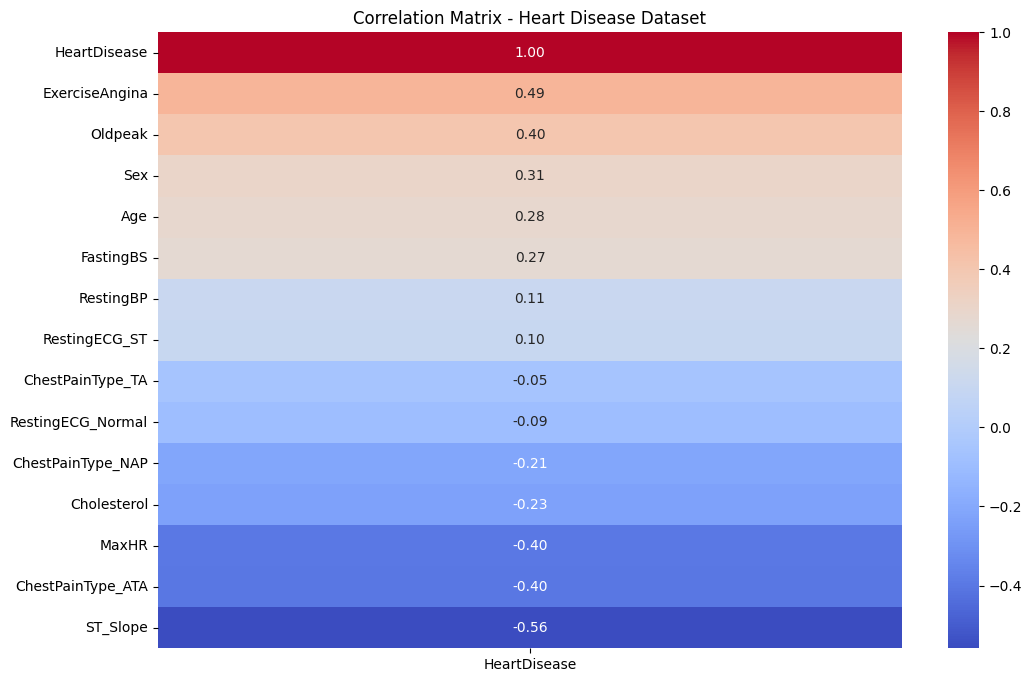

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(target_corr.to_frame(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Heart Disease Dataset")
plt.show()

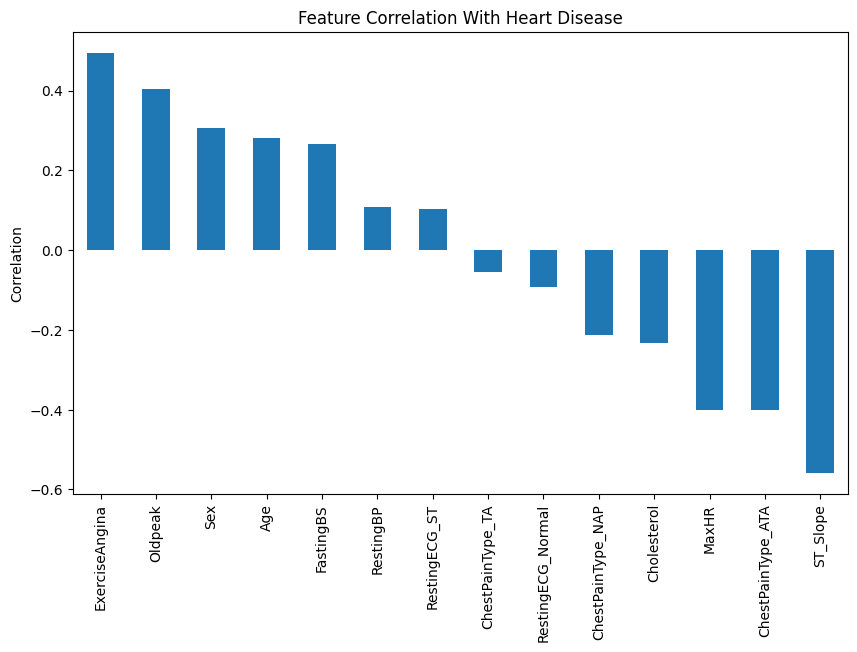

In [ ]:
target_corr.drop("HeartDisease").plot(kind="bar", figsize=(10, 6))

plt.title("Feature Correlation With Heart Disease")
plt.ylabel("Correlation")
plt.show()

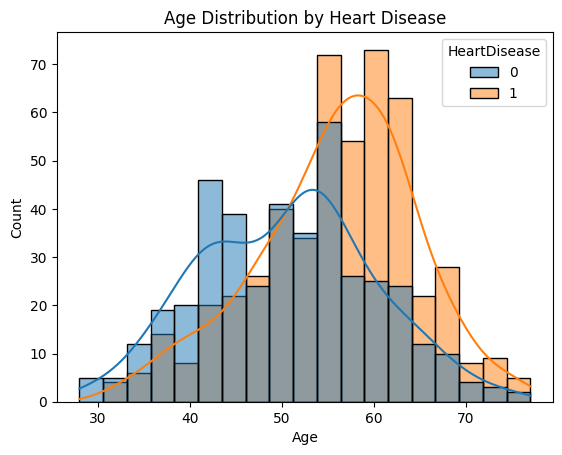

In [ ]:
sns.histplot(data=df, x="Age", hue="HeartDisease", kde=True)

plt.title("Age Distribution by Heart Disease")
plt.show()

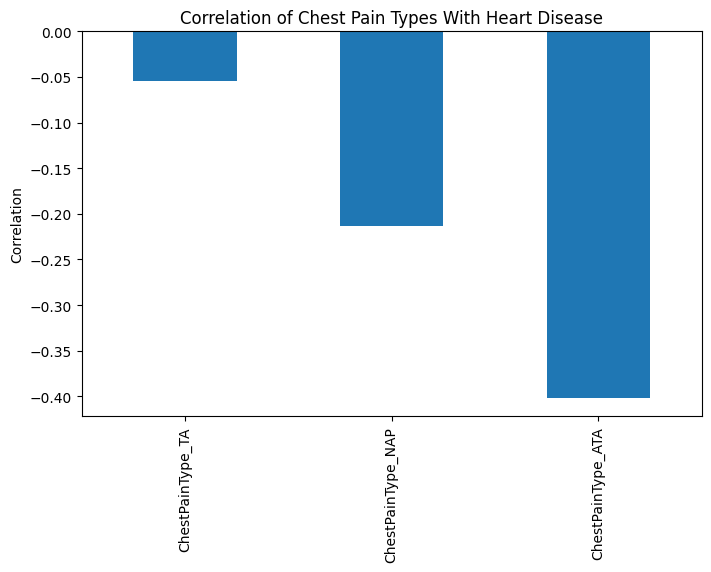

In [ ]:
corr = df.corr()["HeartDisease"].sort_values(ascending=False)

# show only chest pain columns
corr.filter(like="ChestPainType")

cp_corr = corr.filter(like="ChestPainType")

cp_corr.plot(kind="bar", figsize=(8, 5))

plt.title("Correlation of Chest Pain Types With Heart Disease")
plt.ylabel("Correlation")
plt.show()

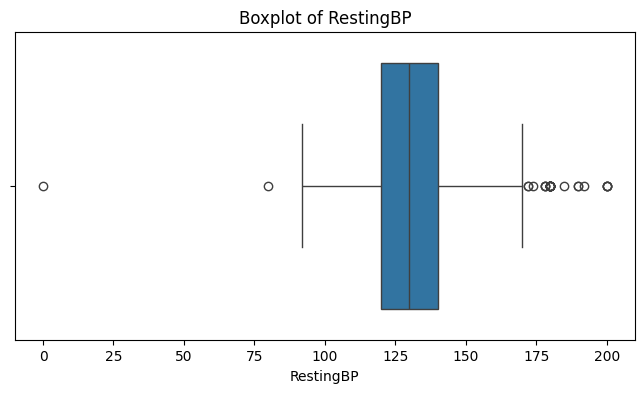

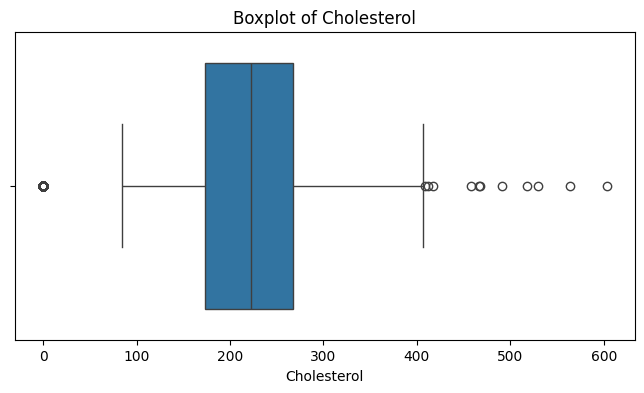

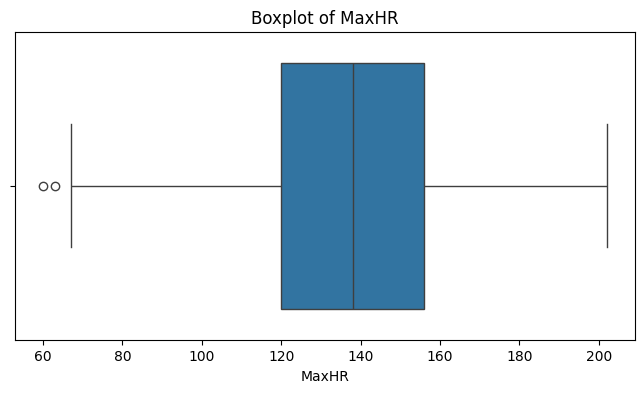

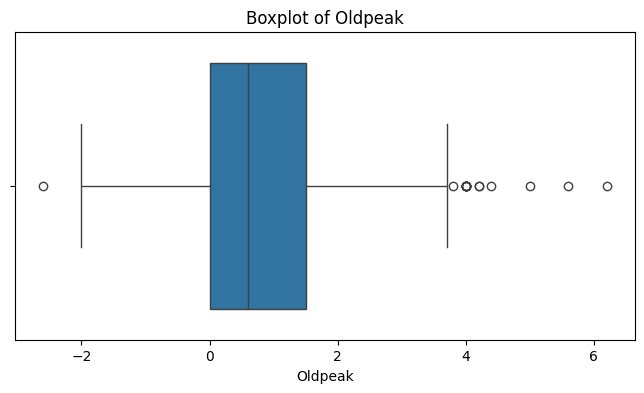

In [ ]:
numerical_features = ["RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f"Boxplot of {feature}")
    plt.show()

In [ ]:
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [ ]:
df.to_csv("df_new.csv", index=False)

In [ ]:
df_new = pd.read_csv("df_new.csv")

In [ ]:
X = df_new.drop("HeartDisease", axis=1)
y = df_new["HeartDisease"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=28),
    "Random Forest": RandomForestClassifier(random_state=28),
    "Gradient Boosting": GradientBoostingClassifier(random_state=28),
    "Support Vector Machine": SVC(random_state=28),
}

In [ ]:
results = []

In [ ]:
for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # If the model supports probability scores, get them for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:  # e.g., SVM without probability=True
        y_prob = model.decision_function(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    # Append results
    results.append(
        {
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1,
            "ROC-AUC": roc,
        }
    )

c:\Users\HP\projects\heartdisease_prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
results_df = pd.DataFrame(results)

In [ ]:
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

In [ ]:
print(results_df)

                    Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
3       Gradient Boosting  0.869565   0.887850  0.887850  0.887850  0.924991
2           Random Forest  0.875000   0.903846  0.878505  0.890995  0.919044
0     Logistic Regression  0.842391   0.890000  0.831776  0.859903  0.912247
1           Decision Tree  0.836957   0.859813  0.859813  0.859813  0.832504
4  Support Vector Machine  0.635870   0.669492  0.738318  0.702222  0.734919


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV

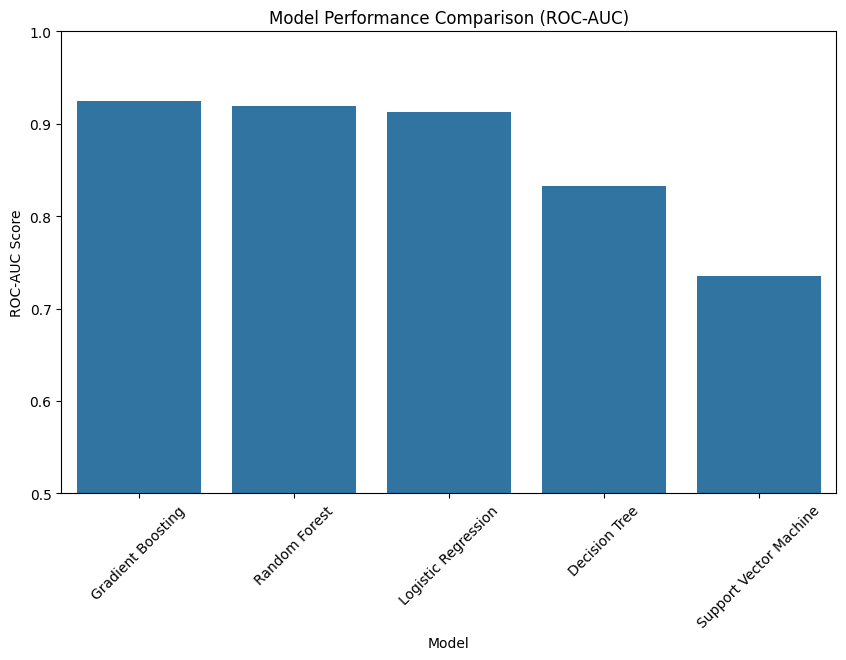

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="ROC-AUC", data=results_df)
plt.title("Model Performance Comparison (ROC-AUC)")
plt.ylabel("ROC-AUC Score")
plt.ylim(0.5, 1)
plt.xticks(rotation=45)
plt.show()

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [ ]:
gb_model = GradientBoostingClassifier(random_state=28) # Best performing model based on ROC-AUC

In [ ]:
# Use GridSearchCV to find the best hyperparameters for the Gradient Boosting model
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=5,
    scoring="recall", # Optimize for recall to minimize false negatives
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_search.fit(X_train, y_train) # Fit the model with the training data

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=28)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fol

In [ ]:
print("Best Parameters:", grid_search.best_params_) # Best hyperparameters
print("Best Recall:", grid_search.best_score_) # Best recall score

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best Recall: 0.9252469135802469


In [ ]:
best_model = grid_search.best_estimator_ # Get the best model with the optimal hyperparameters

In [ ]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

In [ ]:
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1 Score: {f1}")
print(f"ROC-AUC: {roc}")

Accuracy: 0.875
Precision: 0.8888888888888888
Recall: 0.897196261682243
F1 Score: 0.8930232558139535
ROC-AUC: 0.9312416555407209


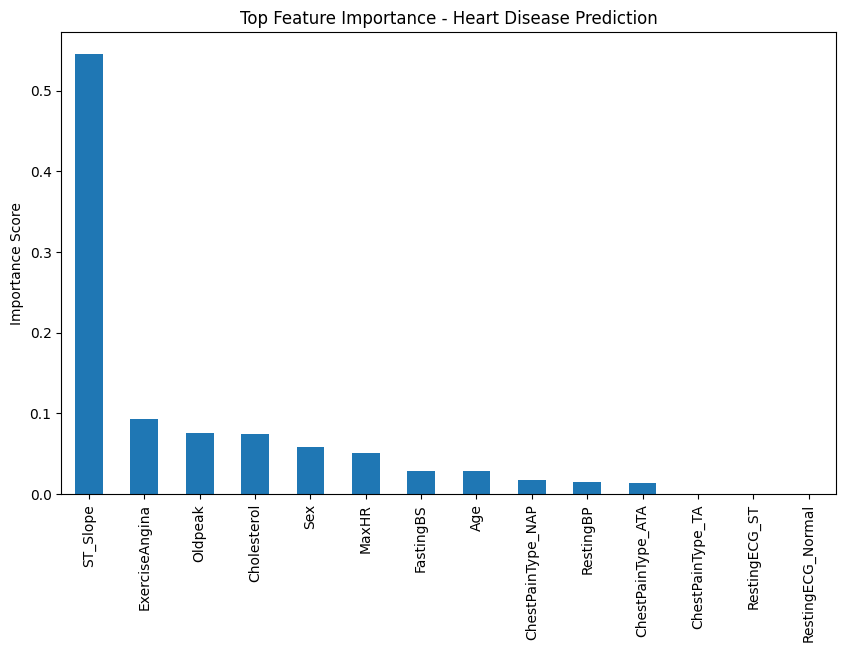

In [ ]:
importance = best_model.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X_train.columns
).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
feature_importance.head(15).plot(kind="bar")

plt.title("Top Feature Importance - Heart Disease Prediction")
plt.ylabel("Importance Score")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

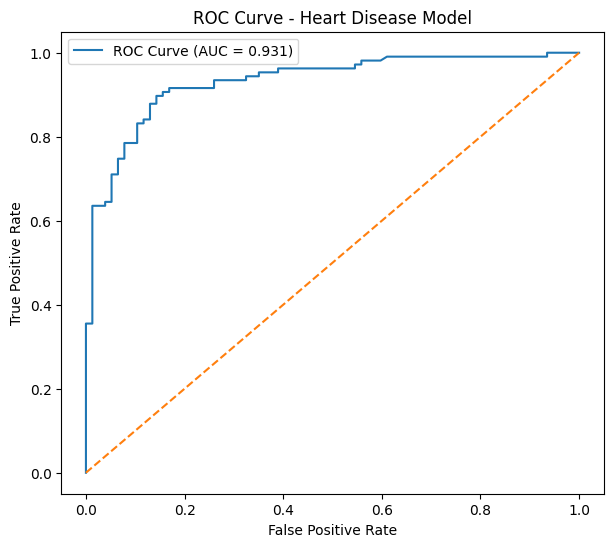

In [ ]:
# Probability predictions
y_prob = best_model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Heart Disease Model")
plt.legend()
plt.show()

In [ ]:
import shap

c:\Users\HP\projects\heartdisease_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


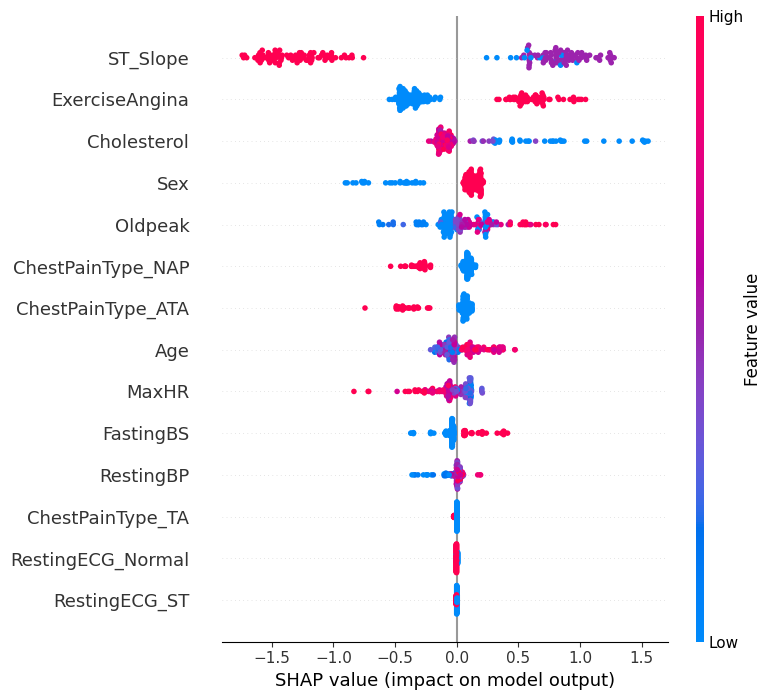

In [ ]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
import joblib

In [ ]:
joblib.dump(best_model, "best_heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [ ]:
joblib.dump(X_train.columns.tolist(), "features.pkl")

['features.pkl']

In [ ]:
import joblib
print(joblib.load("models/features.pkl"))

['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST']
